# Import bibliothèques

In [ ]:
# 📚 Importation des bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 📥 Upload du fichier Excel
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [ ]:
# 📖 Lecture du fichier Excel
import io

# Récupérer le nom du fichier automatiquement
fichier = list(uploaded.keys())[0]

# Lire le fichier
df = pd.read_excel(io.BytesIO(uploaded[fichier]))

# Aperçu rapide des données
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Supprimer les lignes sans CustomerID
df = df.dropna(subset=['CustomerID'])

# Vérification
print("Nombre de lignes restantes :", df.shape[0])

Nombre de lignes restantes : 406829


In [ ]:
# Garder uniquement les ventes (sans "C" dans InvoiceNo)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Vérification rapide
print("Nombre de ventes valides :", df.shape[0])

Nombre de ventes valides : 397924


In [ ]:
# Supprimer les lignes avec des Quantité ou Prix <= 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Vérification
print("Après suppression des valeurs négatives :", df.shape[0])

KeyError: 'Quantity'

In [ ]:
# Calcul du total par ligne
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Aperçu avec la nouvelle colonne
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalPrice']].head()

KeyError: 'Quantity'

In [ ]:
# Convertir en datetime si ce n'est pas déjà fait
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extraire les composants
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['InvoiceWeekday'] = df['InvoiceDate'].dt.day_name()

# Aperçu
df[['InvoiceDate', 'InvoiceYear', 'InvoiceMonth', 'InvoiceDay', 'InvoiceWeekday']].head()

,InvoiceDate,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceWeekday
0,2010-12-01 08:26:00,2010,12,1,Wednesday
1,2010-12-01 08:26:00,2010,12,1,Wednesday
2,2010-12-01 08:26:00,2010,12,1,Wednesday
3,2010-12-01 08:26:00,2010,12,1,Wednesday
4,2010-12-01 08:26:00,2010,12,1,Wednesday


In [ ]:
# Standardiser les noms de colonnes (tout en minuscules, sans espace)
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'totalprice', 'invoicequarter',
       'invoicehour', 'invoiceyear', 'invoicemonth', 'invoiceday',
       'invoiceweekday'],
      dtype='object')

In [ ]:
# Afficher les pays uniques
print(df['country'].unique())

# Voir le top des pays par chiffre d'affaires
df.groupby('country')['totalprice'].sum().sort_values(ascending=False).head(10)

['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Finland' 'Austria' 'Greece' 'Singapore' 'Lebanon'
 'United Arab Emirates' 'Israel' 'Saudi Arabia' 'Czech Republic' 'Canada'
 'Unspecified' 'Brazil' 'USA' 'European Community' 'Bahrain' 'Malta' 'RSA']


,totalprice
country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


In [ ]:
# Sauvegarder en CSV (optionnel)
df.to_csv('online_retail_cleaned.csv', index=False)

In [ ]:
df = pd.read_csv('online_retail_cleaned.csv')

In [ ]:
# Regrouper par produit (description), calculer la somme des quantités vendues
top_products = df.groupby('description')['quantity'].sum()

# Trier du plus vendu au moins vendu
top_products = top_products.sort_values(ascending=False)

# Afficher les 10 premiers
top_products.head(10)

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725
ASSORTED COLOUR BIRD ORNAMENT,35362
PACK OF 72 RETROSPOT CAKE CASES,33693
POPCORN HOLDER,30931
RABBIT NIGHT LIGHT,27202


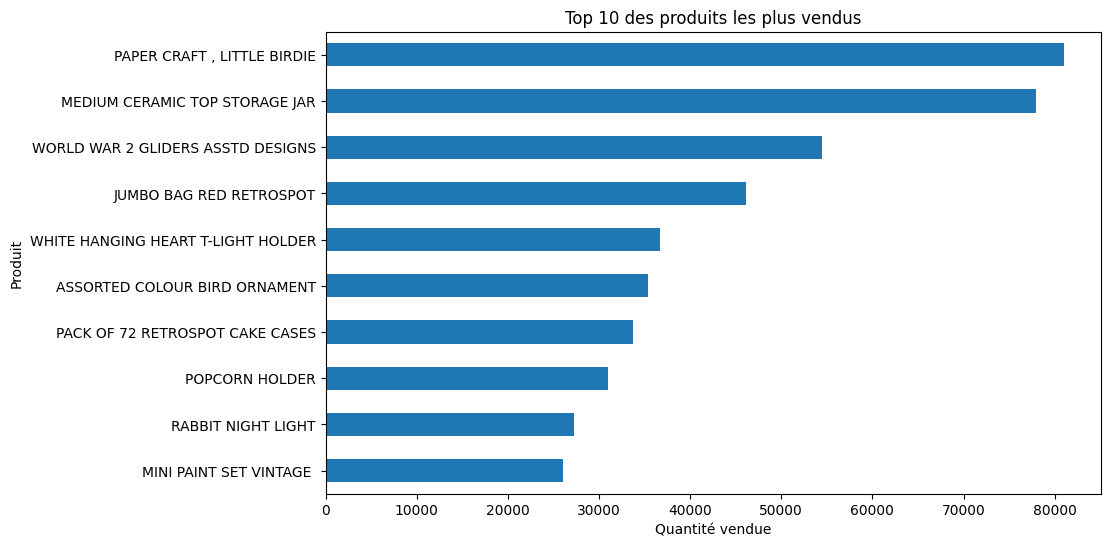

In [ ]:
# Affichage graphique (barres horizontales)
top_products.head(10).plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 des produits les plus vendus')
plt.xlabel('Quantité vendue')
plt.ylabel('Produit')
plt.gca().invert_yaxis()  # Pour avoir le produit le plus vendu en haut
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel(list(uploaded.keys())[0])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Recréer la colonne TotalPrice si elle n’existe pas
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

KeyError: 'Quantity'

In [ ]:
# Somme du chiffre d'affaires par client
top_clients = df.groupby('CustomerID')['TotalPrice'].sum()

# Trier du plus gros acheteur au plus petit
top_clients = top_clients.sort_values(ascending=False)

# Afficher les 10 meilleurs clients
top_clients.head(10)

,TotalPrice
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45
14156.0,113384.14
17511.0,88125.38
16684.0,65892.08
13694.0,62653.10


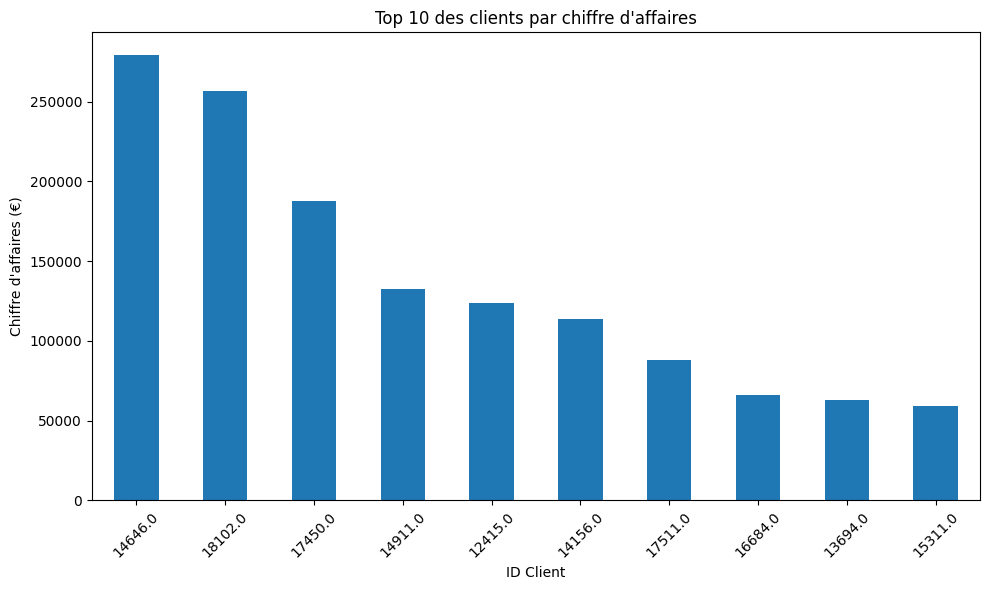

In [ ]:
# Graphique des 10 meilleurs clients
top_clients.head(10).plot(kind='bar', figsize=(10,6))
plt.title('Top 10 des clients par chiffre d\'affaires')
plt.xlabel('ID Client')
plt.ylabel('Chiffre d\'affaires (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

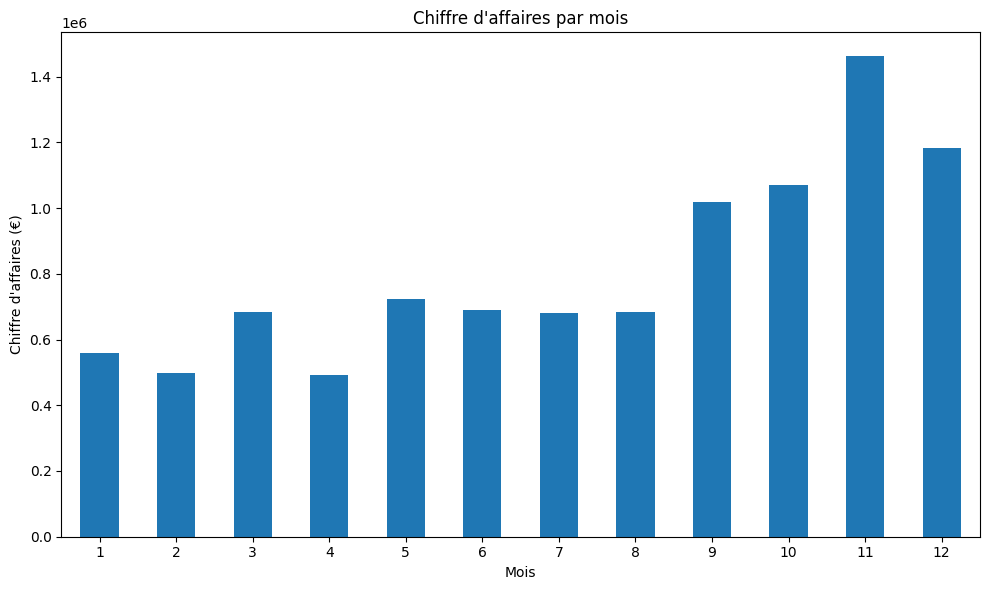

In [ ]:
# Chiffre d'affaires total par mois
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum()

# Affichage
monthly_sales.plot(kind='bar', figsize=(10,6))
plt.title('Chiffre d\'affaires par mois')
plt.xlabel('Mois')
plt.ylabel('Chiffre d\'affaires (€)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

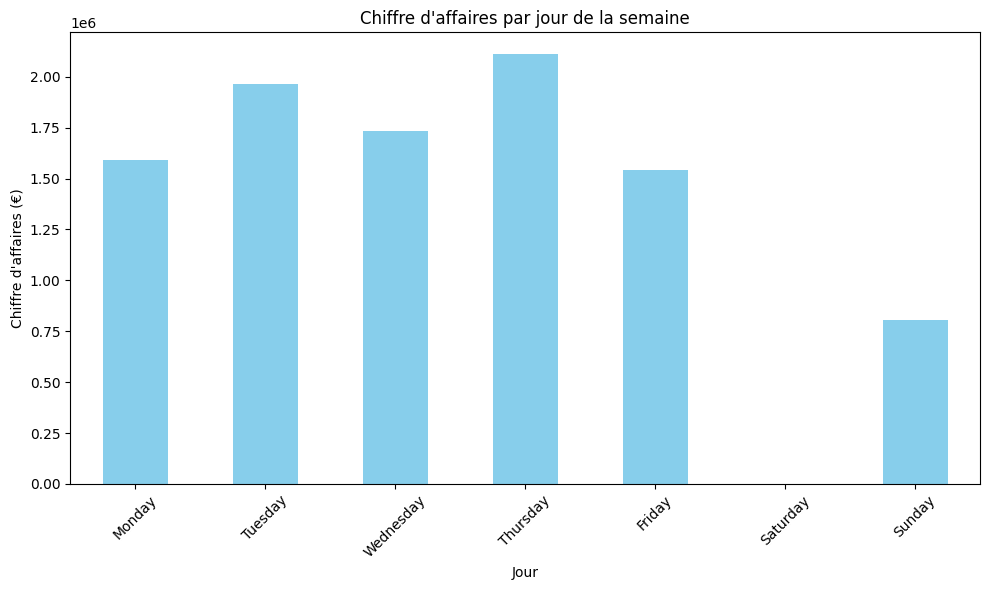

In [ ]:
# Recalculer dans l'ordre des jours (sinon le tri est alphabétique)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Chiifre d'affaires par jour de la semaine
weekday_sales = df.groupby('InvoiceWeekday')['TotalPrice'].sum().reindex(days_order)

# Affichage
weekday_sales.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title('Chiffre d\'affaires par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Chiffre d\'affaires (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Calcul du total par facture
panier_par_commande = df.groupby('InvoiceNo')['TotalPrice'].sum()

# Calcul du panier moyen
panier_moyen = panier_par_commande.mean()

# Affichage
print(f"💰 Panier moyen : {panier_moyen:.2f} €")

💰 Panier moyen : 376.36 €


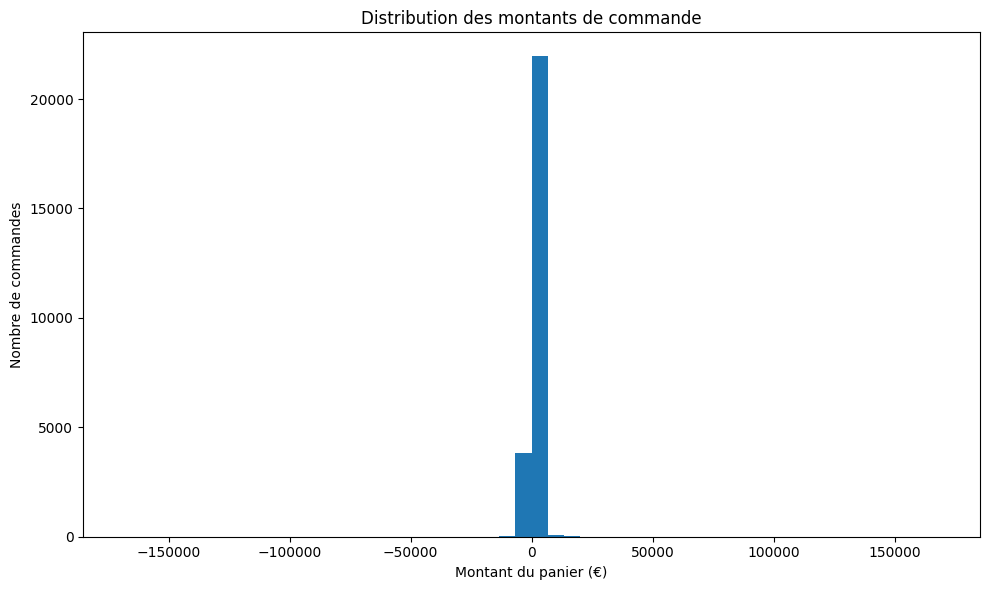

In [ ]:
# Affichage des montants par paniers

panier_par_commande.plot(kind='hist', bins=50, figsize=(10,6))
plt.title('Distribution des montants de commande')
plt.xlabel('Montant du panier (€)')
plt.ylabel('Nombre de commandes')
plt.tight_layout()
plt.show()

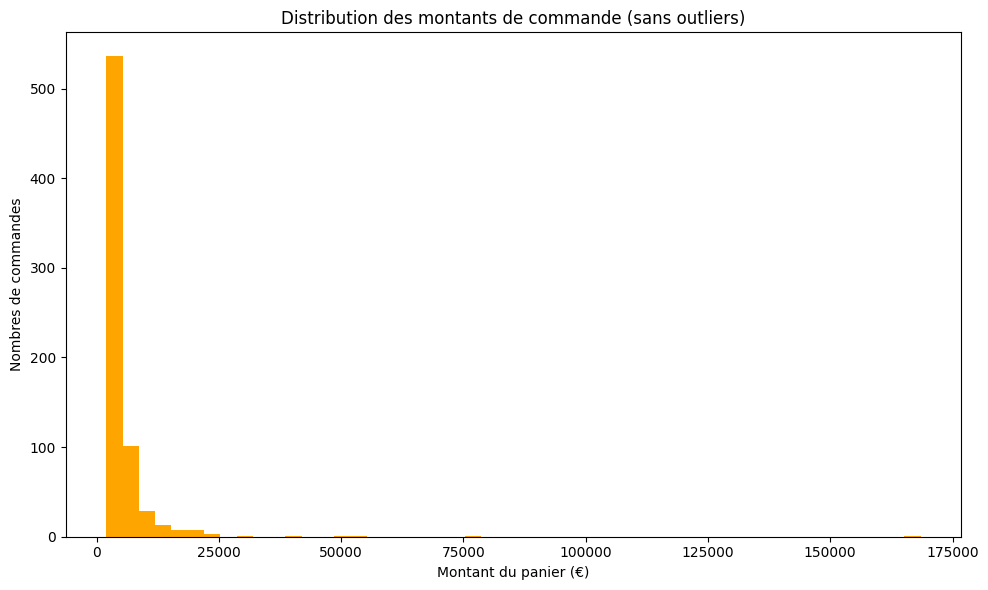

In [ ]:
# Filtrer les commandes avec des montants raisonnables (ex : > 2000 €)
panier_filtré = panier_par_commande[panier_par_commande > 2000]

# Nouvel histogramme (2)
panier_filtré.plot(kind='hist', bins=50, figsize=(10,6), color='orange')
plt.title('Distribution des montants de commande (sans outliers)')
plt.xlabel('Montant du panier (€)')
plt.ylabel('Nombres de commandes')
plt.tight_layout()
plt.show()

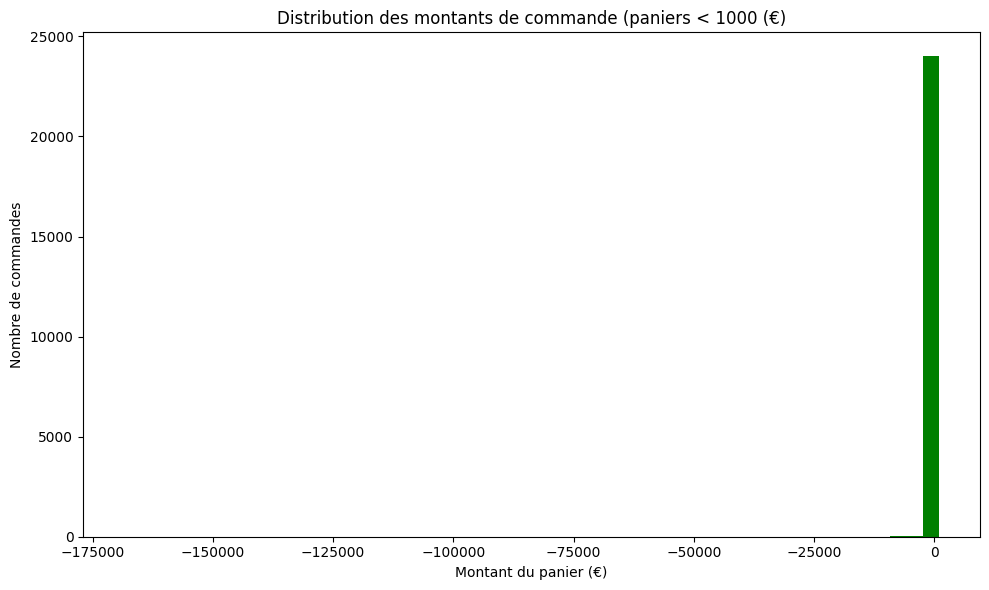

In [ ]:
# Panier sans valeurs extrêmes au-dessus de 1 000 €
panier_filtré = panier_par_commande[panier_par_commande < 1000]

# Affichage du nouvel histogramme (3)
panier_filtré.plot(kind='hist', bins=50, figsize=(10,6), color='green')
plt.title('Distribution des montants de commande (paniers < 1000 (€)')
plt.xlabel('Montant du panier (€)')
plt.ylabel('Nombre de commandes')
plt.tight_layout()
plt.show()

In [ ]:
# Comprendre les valeurs des plus gros paniers
panier_par_commande.sort_values(ascending=False).head(10)

,TotalPrice
InvoiceNo,
581483,168469.60
541431,77183.60
574941,52940.94
576365,50653.91
556444,38970.00
567423,31698.16
556917,22775.93
572209,22206.00
567381,22104.80


In [ ]:
panier_par_commande[panier_par_commande < 0]

,TotalPrice
InvoiceNo,
A563186,-11062.06
A563187,-11062.06
C536379,-27.50
C536383,-4.65
C536391,-141.48
...,...
C581484,-168469.60
C581490,-32.53
C581499,-224.69


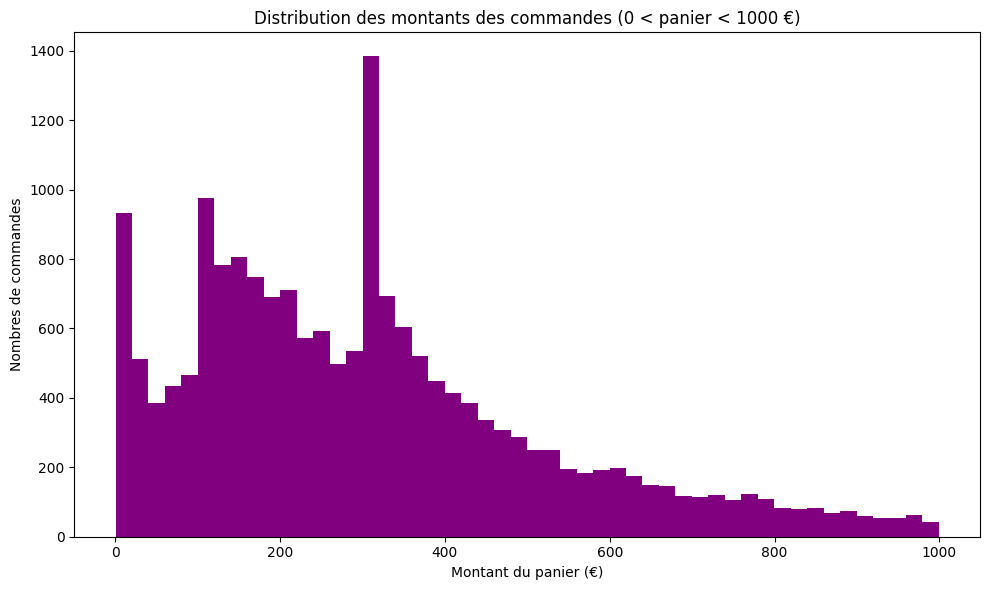

In [ ]:
panier_filtré = panier_par_commande[(panier_par_commande > 0) & (panier_par_commande < 1000)]

# Nouveau histogramme clean (4)
panier_filtré.plot(kind='hist', bins=50, figsize=(10,6), color='purple')
plt.title('Distribution des montants des commandes (0 < panier < 1000 €)')
plt.xlabel('Montant du panier (€)')
plt.ylabel('Nombres de commandes')
plt.tight_layout()
plt.show()

In [ ]:
# Somme du chiffre d'affaires par pays
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# Afficher les 10 premiers pays
top_countries.head(10)

,TotalPrice
Country,
United Kingdom,8187806.364
Netherlands,284661.540
EIRE,263276.820
Germany,221698.210
France,197403.900
Australia,137077.270
Switzerland,56385.350
Spain,54774.580
Belgium,40910.960


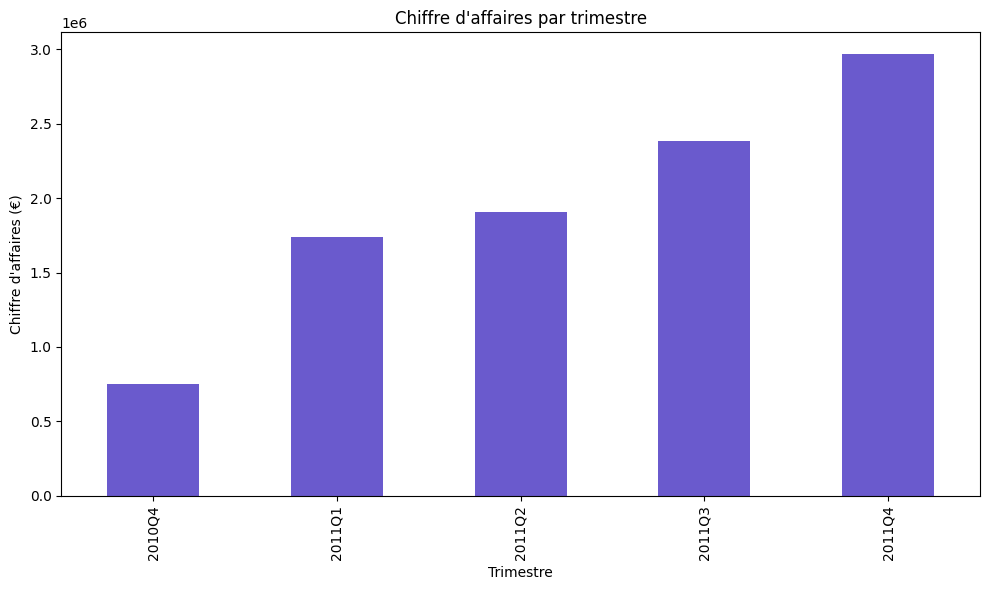

In [ ]:
# Créer une colonne trimestre
df['InvoiceQuarter'] = df['InvoiceDate'].dt.to_period('Q')

# Chiffre d'affaires par trimestre
quarterly_sales = df.groupby('InvoiceQuarter')['TotalPrice'].sum()

# Affichage
quarterly_sales.plot(kind='bar', figsize=(10,6), color='slateblue')
plt.title('Chiffre d\'affaires par trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Chiffre d\'affaires (€)')
plt.tight_layout()
plt.show()

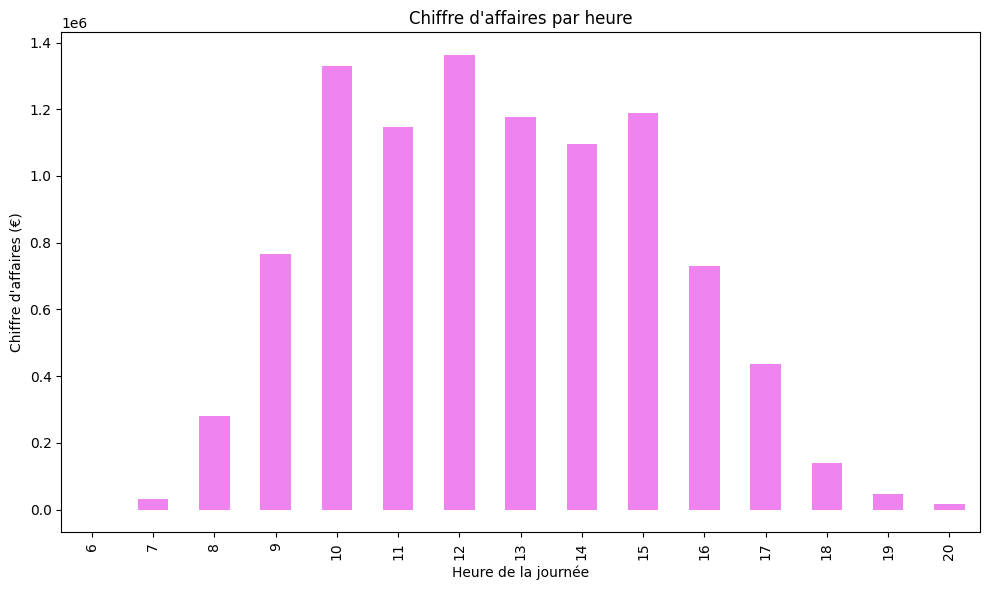

In [ ]:
# Créer une colonne heure
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

# Chiffre d'affaires par heure
hourly_sales = df.groupby('InvoiceHour')['TotalPrice'].sum()

# Affichage
hourly_sales.plot(kind='bar', figsize=(10,6), color='violet')
plt.title('Chiffre d\'affaires par heure')
plt.xlabel('Heure de la journée')
plt.ylabel('Chiffre d\'affaires (€)')
plt.tight_layout()
plt.show()

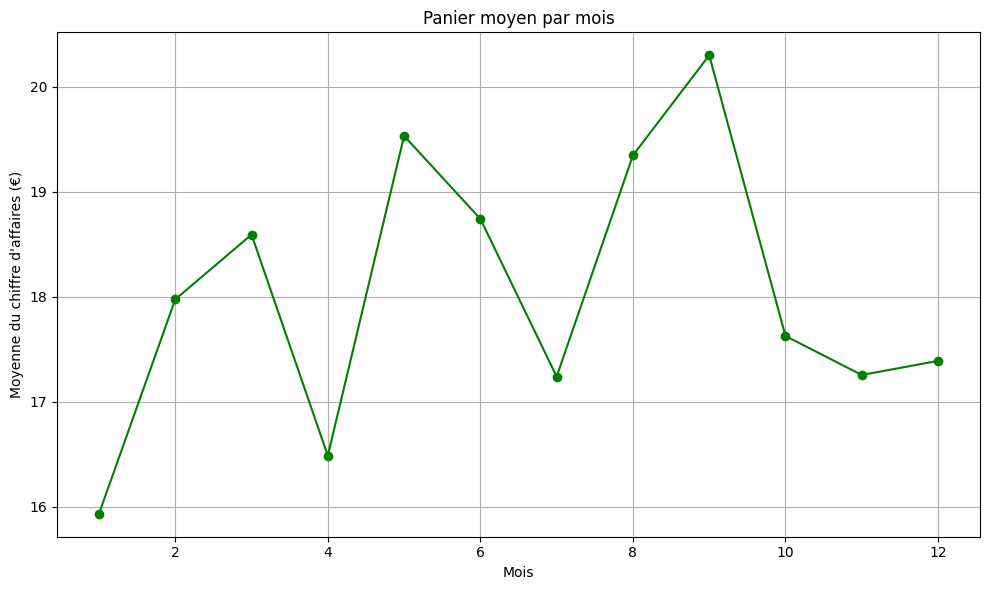

In [ ]:
# Moyenne mensuelle du CA
monthly_avg = df.groupby('invoicemonth')['totalprice'].mean()

# Affichage
monthly_avg.plot(kind='line', marker='o', figsize=(10,6), color='green')
plt.title('Panier moyen par mois')
plt.xlabel('Mois')
plt.ylabel('Moyenne du chiffre d\'affaires (€)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Vérifier les noms de colonne
print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'totalprice', 'invoicequarter',
       'invoicehour', 'invoiceyear', 'invoicemonth', 'invoiceday',
       'invoiceweekday'],
      dtype='object')


In [ ]:
# Afficher les lignes où le jour = samedi
df[df['invoiceweekday'] == 'Saturday']

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,invoicequarter,invoicehour,invoiceyear,invoicemonth,invoiceday,invoiceweekday


# Panier moyen par pays

In [ ]:
# Total dépensé par commande
panier_par_commande = df.groupby('invoiceno')['totalprice'].sum()

# Associer chaque commande à un pays (on prend le premier pays de chaque facture)
pays_par_commande = df.groupby('invoiceno')['country'].first()

# Créer un DateFrame fusionné
panier_par_pays = pd.DataFrame({
    'totalprice': panier_par_commande,
    'country': pays_par_commande
})

# Calcul du panier moyen par pays
avg_panier_par_pays = panier_par_pays.groupby('country')['totalprice'].mean().sort_values(ascending=False)

# Affichage
avg_panier_par_pays.head(10)

,totalprice
country,
Netherlands,2818.431089
Australia,1986.627101
Lebanon,1693.880000
Japan,1262.165000
Brazil,1143.600000
RSA,1002.310000
Singapore,912.039000
Denmark,893.720952
Norway,879.086500


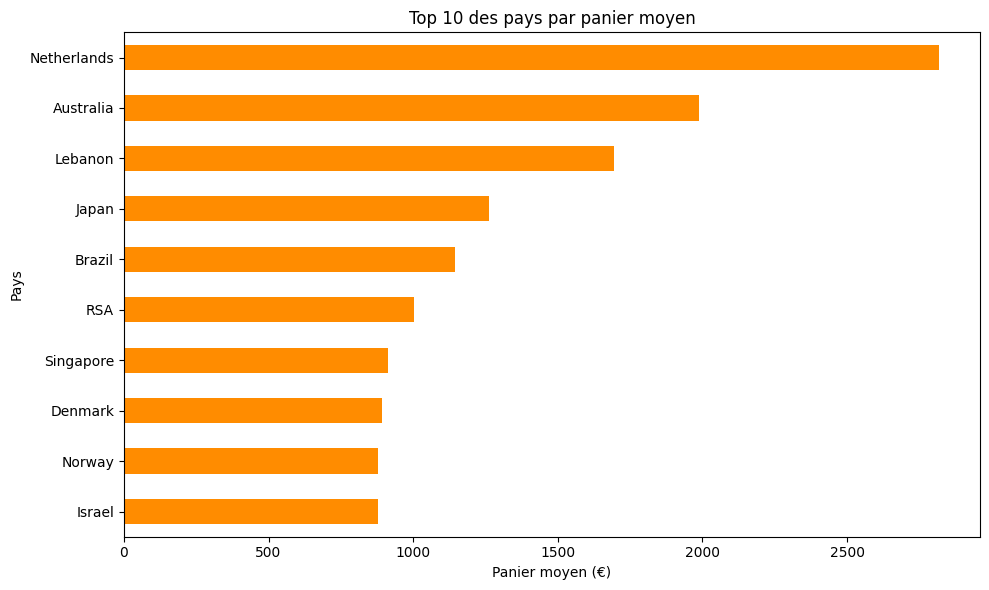

In [ ]:
# Affichage
avg_panier_par_pays.head(10).plot(kind='barh', figsize=(10,6), color='darkorange')
plt.title('Top 10 des pays par panier moyen')
plt.xlabel('Panier moyen (€)')
plt.ylabel('Pays')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Panier moyen par jour de la semaine

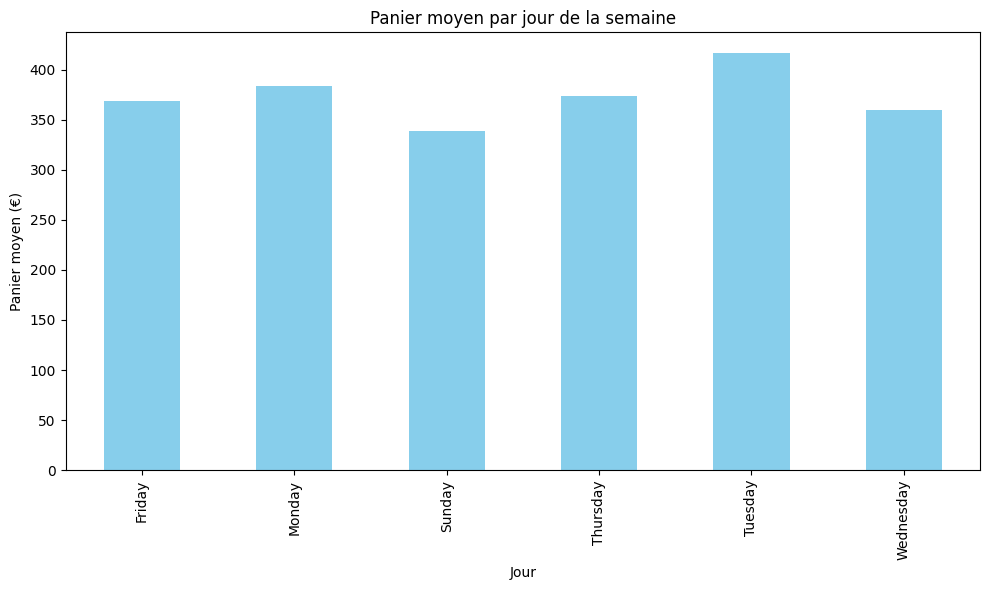

In [ ]:
# Panier moyen par commande
panier_par_commande = df.groupby('invoiceno')['totalprice'].sum()

# Associer chaque commannde à un jour
jour_par_commande = df.groupby('invoiceno')['invoiceweekday].first()

# Fusion
panier_par_jour = pd.DataFrame ({
    'totalprice': panier_par_commande,
    'weekday': jour_par_commande
})

# Moyenne par jour
avg_panier_par_pays = panier_par_jour.groupby('weekday')['totalprice'].mean()

# Ordre des jours
jours_ordre = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Affichage
avg_panier_par_pays.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title('Panier moyen par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Panier moyen (€)')
plt.tight_layout()
plt.show()

# Export DataFrame vers Google Sheets

In [ ]:
# Authentification avec ton compte Google
from google.colab import auth
auth.authenticate_user()

# Importer les bibliothèques
import gspread
from gspread_dataframe import set_with_dataframe
from google.auth import default

# Obtenir les identifiants Google
creds, _ = default()
gc = gspread.authorize(creds)

# Créer une feuille Google Sheet nommée "Online Retrail Cleaned"
sh = gc.create('Online Retrail Cleaned')
worksheet = sh.get_worksheet(0) or sh.sheet1
worksheet.clear()

# Envoyer le DataFrame dans la feuille
set_with_dataframe(worksheet, df)

# Obtenir l'URL de la feuille
print('✅ Feuille créee avec succès :', sh.url)

✅ Feuille créee avec succès : https://docs.google.com/spreadsheets/d/1fYmgmAlQIKVI1UPG5oT-27ztYRCAmJOGZQoFZBX5SdQ
